In [ ]:
!pip install bertopic
!pip install nltk
# !pip install keybert
# !pip install keyphrase-vectorizers
# !pip install ctransformers[cuda]
# !pip install --upgrade git+https://github.com/huggingface/transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [ ]:
import pandas as pd
import numpy as np
import torch
import transformers
from bertopic import BERTopic
import os
from sentence_transformers import SentenceTransformer
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
from transformers import AutoTokenizer, pipeline
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import TextGeneration
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import openai
import lightgbm as lgb
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
import plotly.express as px
import seaborn as sns
import shap
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [ ]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
df1 = pd.read_csv('../data/letters_2021_processed.csv')
df1 = df1[['s1_s2', 'full_text', 'LETTER_GENDER']]
df1 = df1.rename(columns={'LETTER_GENDER':'label'})

In [ ]:
df2 = pd.read_csv('../data/sentence_sets_trimmed_processed.csv')
df2 = df2[['s1_s2', 'full_text', 'applicant_gender']]
df2 = df2.rename(columns={'applicant_gender':'label'})

In [ ]:
df = pd.concat([df1, df2], ignore_index=True)

In [ ]:
gender_label_mapping = {
    'F':0,
    'female':0,
    'M':1,
    'male':1
}

In [ ]:
df['label'] = df['label'].replace(gender_label_mapping)

# Process Data

In [ ]:
df['s1_s2'] = df['s1_s2'].str.replace(r'identifier', '', case=False, regex=True).str.strip()
df['s1_s2'] = df['s1_s2'].str.replace(r'mx', '', case=False, regex=True).str.strip()

In [ ]:
letters = df['s1_s2']
sentences = [sent_tokenize(letter) for letter in letters]
sentences = pd.concat([df, pd.Series(sentences, name='sentences')], axis=1)
sentences = sentences[['sentences']].explode('sentences')
df_sentences = pd.merge(df, sentences, left_index=True, right_index=True)

# Topic Modeling

In [ ]:
topic_model = BERTopic.load("../saved_models/topic_model_pca_kmeans")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling%2Fconfig.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = embedding_model.encode(sentences['sentences'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/4850 [00:00<?, ?it/s]

In [ ]:
topics, probs = topic_model.transform(df_sentences['sentences'].tolist(), embeddings)

2025-02-14 13:49:08,051 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,MMR,POS,Representative_Docs
0,0,9601,0_patients_staff_families_patients families,"[patients, staff, families, patients families,...","[patients colleagues, patients ease, caring pa...","[patients families, bedside manner, rapport pa...","[patients, staff, families, bedside, rapport, ...",NaN
1,1,7081,1_hard_personality_hard working_ethic,"[hard, personality, hard working, ethic, demea...","[qualities, positive attitude, demeanor, perso...","[personality, hard working, demeanor, work eth...","[hard, personality, ethic, demeanor, humble, i...",NaN
2,2,6943,2_room_operating_operating room_patient,"[room, operating, operating room, patient, icu...","[preoperative, patients, inpatient, operating ...","[operating room, icu, patients, procedures, ai...","[room, operating, patient, icu, care, patients...",NaN
3,3,6725,3_residency program_residency_program_resident,"[residency program, residency, program, reside...","[recommend residency, residency program, progr...","[residency program, addition residency, recomm...","[residency, program, resident, asset, excellen...",NaN
4,4,6717,4_anesthesiologist_anesthesiology_career_caree...,"[anesthesiologist, anesthesiology, career, car...","[excellent anesthesiologist, future anesthesio...","[anesthesiologist, career anesthesiology, fiel...","[anesthesiologist, anesthesiology, career, fie...",NaN
5,5,6634,5_medical students_students_medical student_st...,"[medical students, students, medical student, ...","[medical students, medical student, student me...","[medical students, students, medical student, ...","[medical students, students, medical student, ...",NaN
6,6,6512,6_patient_patients_questions_treatment,"[patient, patients, questions, treatment, plan...","[patient presentations, clinical, patients, pl...","[patients, questions, rounds, plans, diagnoses...","[patient, patients, questions, treatment, roun...",NaN
7,7,6324,7_physician_medical knowledge_clinical_excelle...,"[physician, medical knowledge, clinical, excel...","[excellent physician, great physician, physici...","[physician, medical knowledge, excellent physi...","[physician, medical knowledge, clinical, excel...",NaN
8,8,6309,8_clerkship_internal medicine_hospital_internal,"[clerkship, internal medicine, hospital, inter...","[medicine clerkship, medical center, attending...","[clerkship, internal medicine, hospital, clini...","[clerkship, internal medicine, hospital, inter...",NaN
9,9,6294,9_university_school_medical school_college,"[university, school, medical school, college, ...","[medical college, medical school, college medi...","[university, medical school, graduated, underg...","[school, medical school, degree, undergraduate...",NaN


In [ ]:
topic_mapping = {
    0: 'patient care',
    1: 'hard working',
    2: 'operating room terminology',
    3: 'residency',
    4: 'promising anesthesiology career',
    5: 'excellent medical student',
    6: 'excellent at patient assessment',
    7: 'excellent future physician',
    8: 'clerkship',
    9: 'academic achievements',
    10: 'anesthesia knowledge',
    11: 'medical knowledge',
    12: 'excellent student',
    13: 'project/research studies',
    14: 'went above and beyond',
    15: 'impressive attitude and demeanor',
    16: 'recommendation language',
    17: 'anesthesiology elective',
    18: 'eager learner',
    19: 'asked intelligent questions',
    20: 'team player',
    21: 'pleasure to work with',
    22: 'project/research publications',
    23: 'motivated/mature/professional',
    24: 'strong asset',
    25: 'recommendation letter language',
    26: 'recommendation letter language 1',
    27: 'recommendation letter language 2',
    28: 'recommendation letter language 3',
    29: 'recommendation letter language 4'
}

topic_model.set_topic_labels(topic_mapping)
topic_mapping = dict(zip(topic_model.get_topic_info()['Topic'], topic_model.get_topic_info()['CustomName']))
topic_mapping = {f'topic_{key}': value for key, value in topic_mapping.items()}

# Create Topics Dataframe

In [ ]:
df_sentences['topic'] = topics

In [ ]:
topics_df = df_sentences.copy()
topics_df['topic'] = topics_df['topic'].astype(str)
topics_df = topics_df.groupby(topics_df.index).agg({'topic':' '.join})
topics_df = pd.DataFrame(topics_df)
topics_df = topics_df['topic'].apply(lambda x:x.split(' '))
topics_df = topics_df.reset_index()
all_topics = set(cat for sublist in topics_df['topic'] for cat in sublist)
for topic in all_topics:
    topics_df[topic] = topics_df['topic'].apply(lambda x: 1 if topic in x else 0)
topics_df = topics_df.drop(columns=['index', 'topic'])
topics_df.columns = 'topic_' + topics_df.columns
df_sentences_collapsed = df_sentences[['s1_s2', 'full_text', 'label']].drop_duplicates()
topics_df = pd.merge(df_sentences_collapsed, topics_df, left_index=True, right_index=True)

# Build ML Model

In [ ]:
X = topics_df.drop(columns=['s1_s2', 'full_text', 'label'])
y = topics_df['label']

In [ ]:
X = X.rename(columns=topic_mapping)
X = X.drop(columns=[col for col in X.columns if "recommendation" in col.lower()])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
clf = lgb.LGBMClassifier(is_unbalanced=True, metric='auc', n_estimators = 2000, random_state=0, verbose=-1)

In [ ]:
best_classifier = None
best_f1_score = float('-inf')
for i, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    print(f"Fold {i}:")
    # print(f"  Train: index={train_index}")
    # print(f"  Test:  index={val_index}")

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    clf.fit(X_train_fold, y_train_fold)

    y_pred = clf.predict(X_val_fold)

    print(classification_report(y_val_fold, y_pred))

    print(confusion_matrix(y_val_fold, y_pred))

    f1 = f1_score(y_val_fold, y_pred, average='weighted')

    if f1 > best_f1_score:
      print('BEST F1 SCORE: ', f1)
      best_f1_score = f1
      best_classifier = clf






Fold 0:
              precision    recall  f1-score   support

           0       0.25      0.17      0.20       446
           1       0.67      0.78      0.72       991

    accuracy                           0.59      1437
   macro avg       0.46      0.47      0.46      1437
weighted avg       0.54      0.59      0.56      1437

[[ 74 372]
 [219 772]]
BEST F1 SCORE:  0.5608886918982613
Fold 1:
              precision    recall  f1-score   support

           0       0.36      0.22      0.27       446
           1       0.70      0.82      0.76       991

    accuracy                           0.63      1437
   macro avg       0.53      0.52      0.51      1437
weighted avg       0.59      0.63      0.61      1437

[[ 98 348]
 [178 813]]
BEST F1 SCORE:  0.6053241576538622
Fold 2:
              precision    recall  f1-score   support

           0       0.32      0.23      0.27       446
           1       0.69      0.78      0.73       991

    accuracy                           0.6

Most Important Features:
                             Feature  Importance
13         excellent medical student        3131
14   promising anesthesiology career        2942
5                       hard working        2928
16        excellent future physician        2926
8                          residency        2921
17                 medical knowledge        2910
2                        team player        2864
4         operating room terminology        2719
7                  excellent student        2712
18                     eager learner        2683
6                          clerkship        2642
23                      strong asset        2543
12  impressive attitude and demeanor        2439
3        asked intelligent questions        2428
0               anesthesia knowledge        2393
11           anesthesiology elective        2370
1                       patient care        2368
15             pleasure to work with        2339
10   excellent at patient assessment        

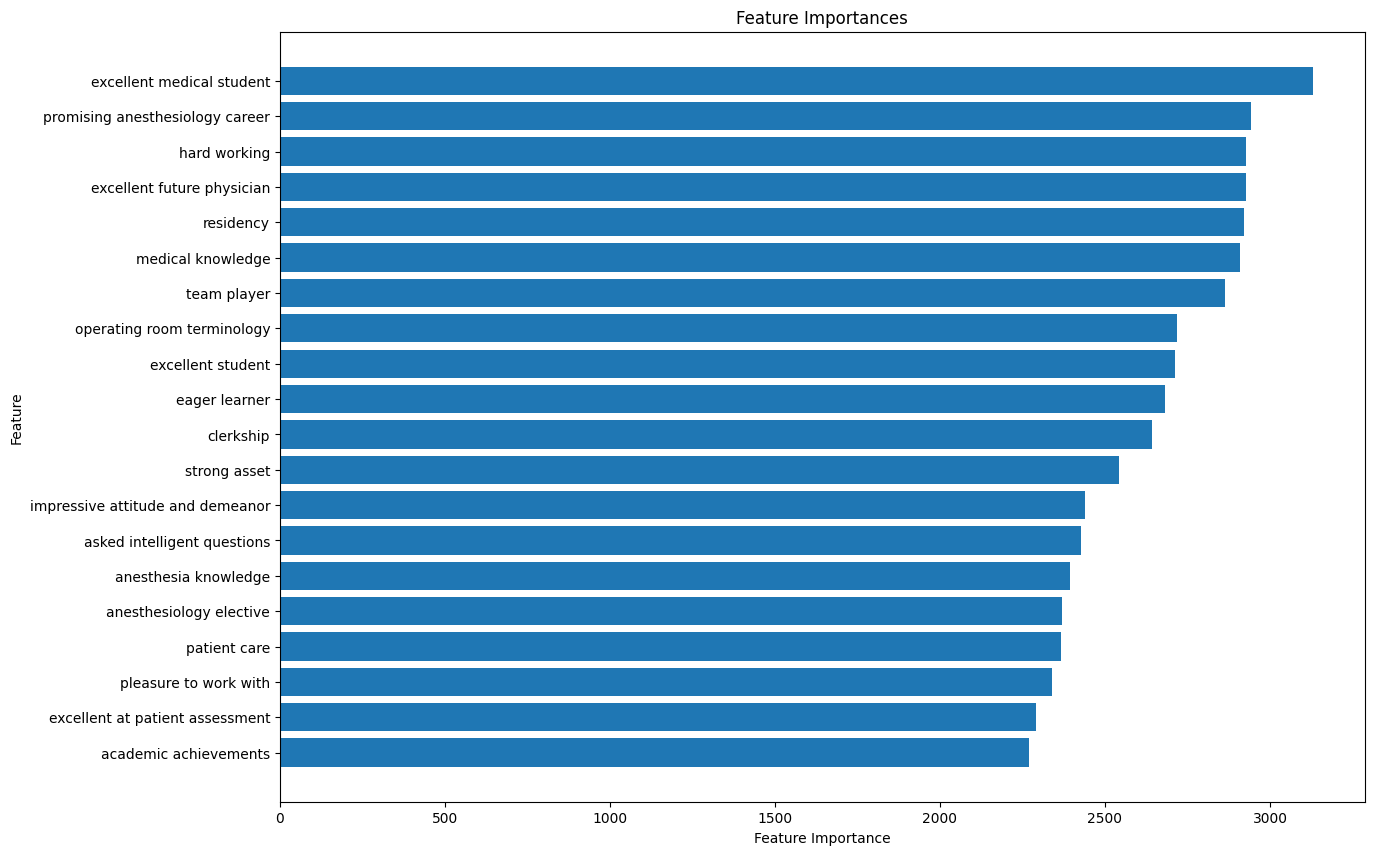

In [ ]:
importances = best_classifier.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)[:20]
#feature_importance_df['Feature'] = feature_importance_df['Feature'].map(topic_mapping)

print("Most Important Features:")
print(feature_importance_df)

plt.figure(figsize=(14, 10))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')

plt.gca().invert_yaxis()

plt.show()

# Apply on Test Set

In [ ]:
y_test_preds = best_classifier.predict(X_test)

In [ ]:
print(classification_report(y_test, y_test_preds))

              precision    recall  f1-score   support

           0       0.33      0.22      0.26       557
           1       0.69      0.80      0.75      1239

    accuracy                           0.62      1796
   macro avg       0.51      0.51      0.50      1796
weighted avg       0.58      0.62      0.59      1796



# Analyze Important Topics

In [ ]:
reduced_embeddings = PCA(n_components=2).fit_transform(embeddings)
fig = topic_model.visualize_documents(sentences['sentences'].tolist(), hide_annotations=True, reduced_embeddings=reduced_embeddings, custom_labels=True)
fig.write_html("interactive_topic_document_plot.html")
fig

Output hidden; open in https://colab.research.google.com to view.

# Analyze Topic By Gender

In [ ]:
topic_percentages = []
for i in range(30):
  topic_num = i
  female = topics_df[topics_df[f'topic_{topic_num}'] == 1]['label'].value_counts()[0] / topics_df['label'].value_counts()[0]
  male = topics_df[topics_df[f'topic_{topic_num}'] == 1]['label'].value_counts()[1] / topics_df['label'].value_counts()[1]
  if (abs(male - female) > .03):
    topic_percentages.append({'topic':f"topic_{topic_num}", "male":male, "female":female})


In [ ]:
topic_percentages_df = pd.DataFrame(topic_percentages)
topic_percentages_df = pd.melt(topic_percentages_df, id_vars=["topic"], value_vars=["male", "female"], var_name="gender", value_name="percentage occurance in letters")
topic_percentages_df['topic'] = topic_percentages_df['topic'].map(topic_mapping)

In [ ]:
topic_percentages_df

,topic,gender,percentage occurance in letters
0,promising anesthesiology career,male,0.467388
1,academic achievements,male,0.331127
2,excellent student,male,0.392477
3,project/research publications,male,0.257507
4,strong asset,male,0.349370
5,promising anesthesiology career,female,0.503948
6,academic achievements,female,0.383345
7,excellent student,female,0.426777
8,project/research publications,female,0.305815
9,strong asset,female,0.398421


Text(0.5, 1.0, 'Percentage of Recommendation Letters Containing Topic by Gender')

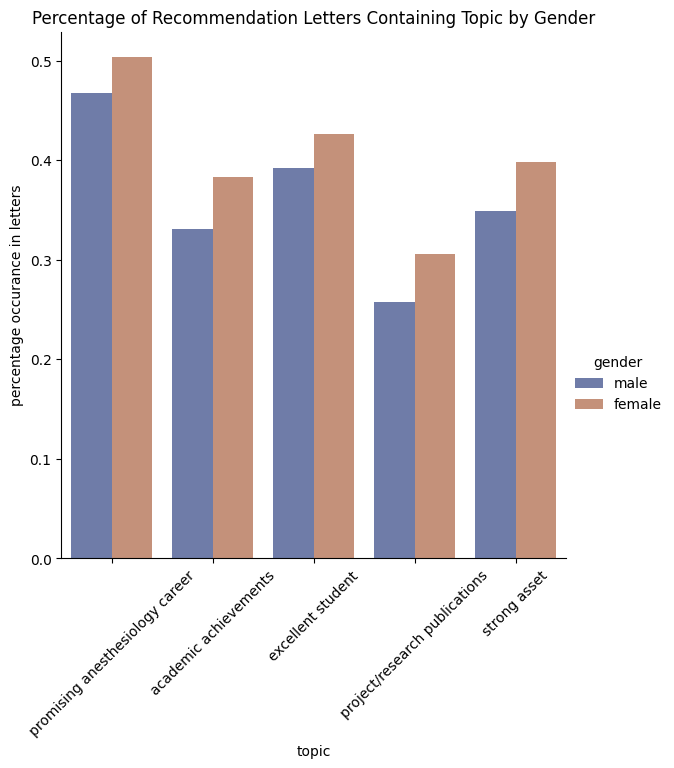

In [ ]:
g = sns.catplot(
    data=topic_percentages_df, kind="bar",
    x="topic", y="percentage occurance in letters", hue="gender",
    errorbar="sd", palette="dark", alpha=.6, height=6
)
g.set_xticklabels(rotation=45)
g.ax.set_title('Percentage of Recommendation Letters Containing Topic by Gender')

# SHAP

In [ ]:
# X_train = X_train.rename(columns=topic_mapping)
# X_test = X_test.rename(columns=topic_mapping)

In [ ]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_test)

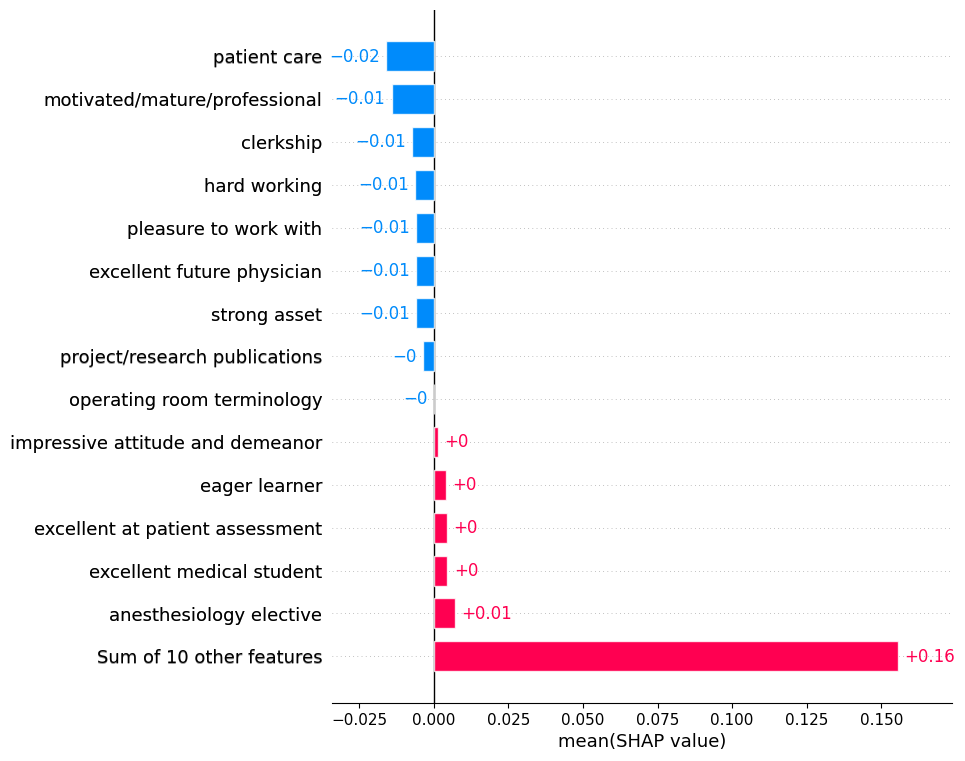

In [ ]:
shap.plots.bar(shap_values.mean(0), order=shap.Explanation.argsort, max_display=15)

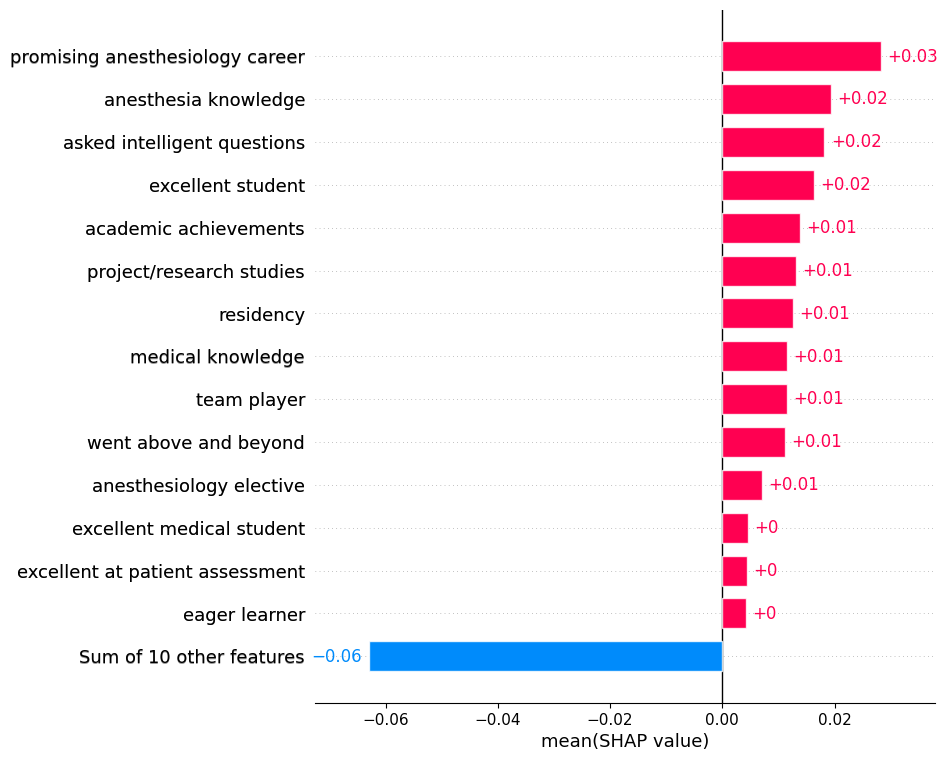

In [ ]:
shap.plots.bar(shap_values.mean(0), order=shap.Explanation.argsort[::-1], max_display=15)

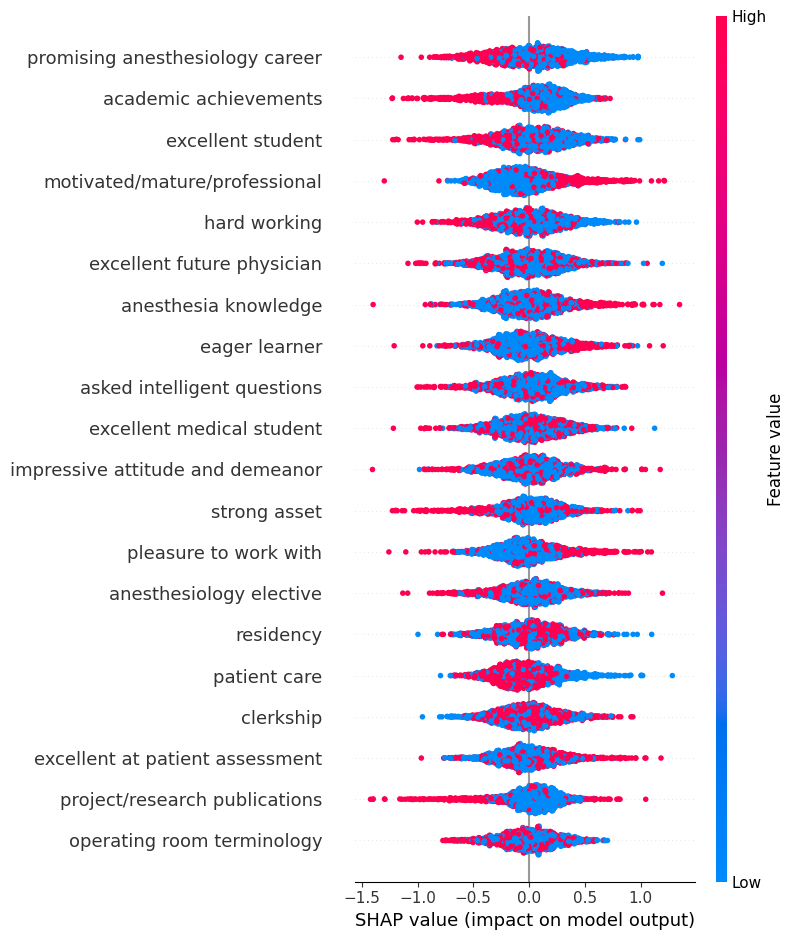

In [ ]:
shap.summary_plot(shap_values, X_test)